# Candidate Experiment 4 — funding-access feasibility
## Summary
**NO-GO for pooled LGA × disaster Category C modelling with these records.** This is a descriptive feasibility audit, not a forecasting experiment.

There are **30 C-positive events, eight mixed-C events and zero verified eligible negatives**. A raw C-zero flag is not a denial. Two such zeros conflict with named geographic eligibility in an official C program. Activation does not establish payment.

Read the [A–K report](results/feasibility_report.md) for the full evidence and unresolved cases. Experiments 1–3 remain frozen.

## 1. Scope and reproducibility
Question: can pre-disaster council capacity add information about extraordinary assistance access after independent disaster need is measured?

We first test the outcome, eligible comparison population, decision unit, timing and coverage. We do not infer eligibility from a zero, make a need/capacity index, impute unknowns, or fit models. The helper contains the full inspectable table-building and plotting code; curated JSON files contain source-reviewed evidence, not inferred labels. Running this cell rebuilds **only Experiment 4** and checks hashes of all 737 pre-existing files before and after. Requires pandas, numpy, matplotlib and IPython; no network is needed.

In [1]:
from pathlib import Path
import json, runpy, contextlib, io
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "NSW Data Panel.csv").exists())
OUT = ROOT / "Experiment 4/related/funding_access/results"
with contextlib.redirect_stdout(io.StringIO()):
    audit = runpy.run_path(str(OUT / "build_audit.py"))
checks = json.loads((OUT / "validation_checks.json").read_text())
def table(name):
    return pd.read_csv(OUT / f"{name}.csv")
def figure(name, width=850):
    display(Image(filename=str(OUT / "figures" / f"{name}.png"), width=width))
print(f"Frozen files verified: {checks['frozen_files_checked']}; models fitted: {checks['models_fitted']}")

Frozen files verified: 737; models fitted: 0


## 2. Verify the activation backbone
Use LGA rows separately from SAL rows. AGRN is an event identifier, not an independent funding-decision identifier. The field dictionary distinguishes official policy meaning from unverified CSV encoding. The publisher's downloadable CSV matches the supplied file byte for byte; its snapshot is not an activation decision date.

,Verified count
rows,2475
lga_rows,2305
sal_rows,170
events,378
C_rows,687
D_rows,993
C_events,30
mixed_C_events,8
D_events,42
mixed_D_events,11


Onset range: 2017-09-08 to 2026-06-29
Missing raw fields: {'hazard_type': 1}


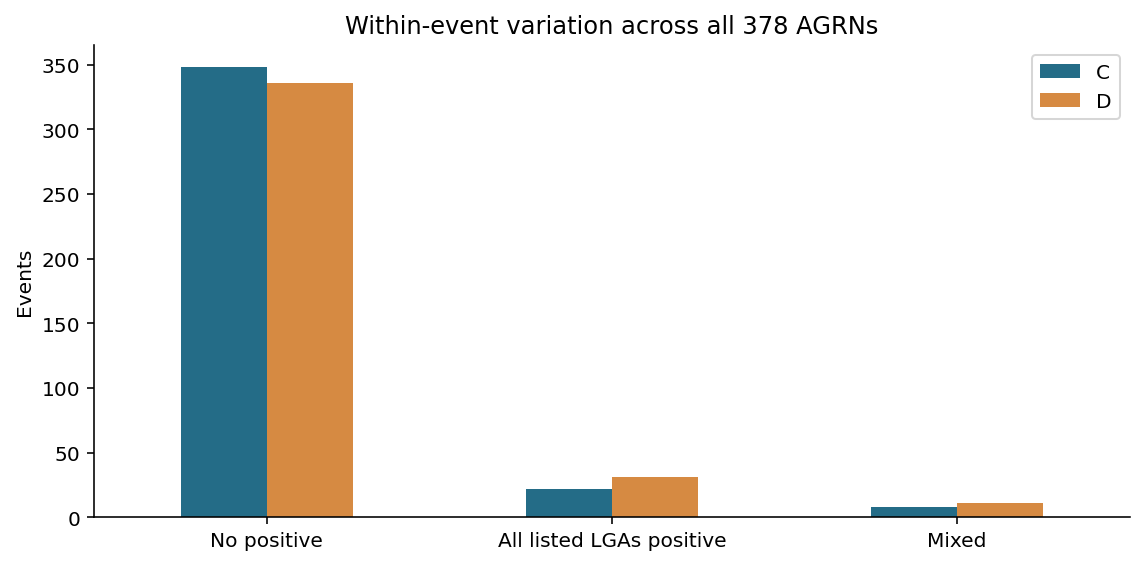

In [2]:
backbone = audit["d"]
display(pd.Series({k: checks[k] for k in ["rows", "lga_rows", "sal_rows", "events", "C_rows", "D_rows", "C_events", "mixed_C_events", "D_events", "mixed_D_events"]}, name="Verified count").to_frame())
print("Onset range:", backbone.disaster_start_date.min(), "to", backbone.disaster_start_date.max())
print("Missing raw fields:", backbone.isna().sum().loc[lambda s: s.gt(0)].to_dict())
figure("03_within_event_variation")

## 3. Decision unit and genuine comparisons
Of 30 C-positive events, 22 have C=1 for every listed LGA. Eight are mixed, but mixed flags alone do not establish eligible untreated areas. Programs within one C event can serve different regions, industries or recipients. Treat the counts below as locations, not independent decisions. Complete measure inventories remain uncertified.

,agrn,state,n_lga_rows,cat_C_positive,cat_C_zero
55,960,New South Wales,79,78,1
129,1037,Victoria,65,64,1
130,1038,Tasmania,18,17,1
135,1046,Queensland,45,5,40
280,1174,Queensland,40,38,2
292,1202,Queensland,41,40,1
346,1243,Queensland,65,62,3
372,1269,Northern Territory,13,10,3


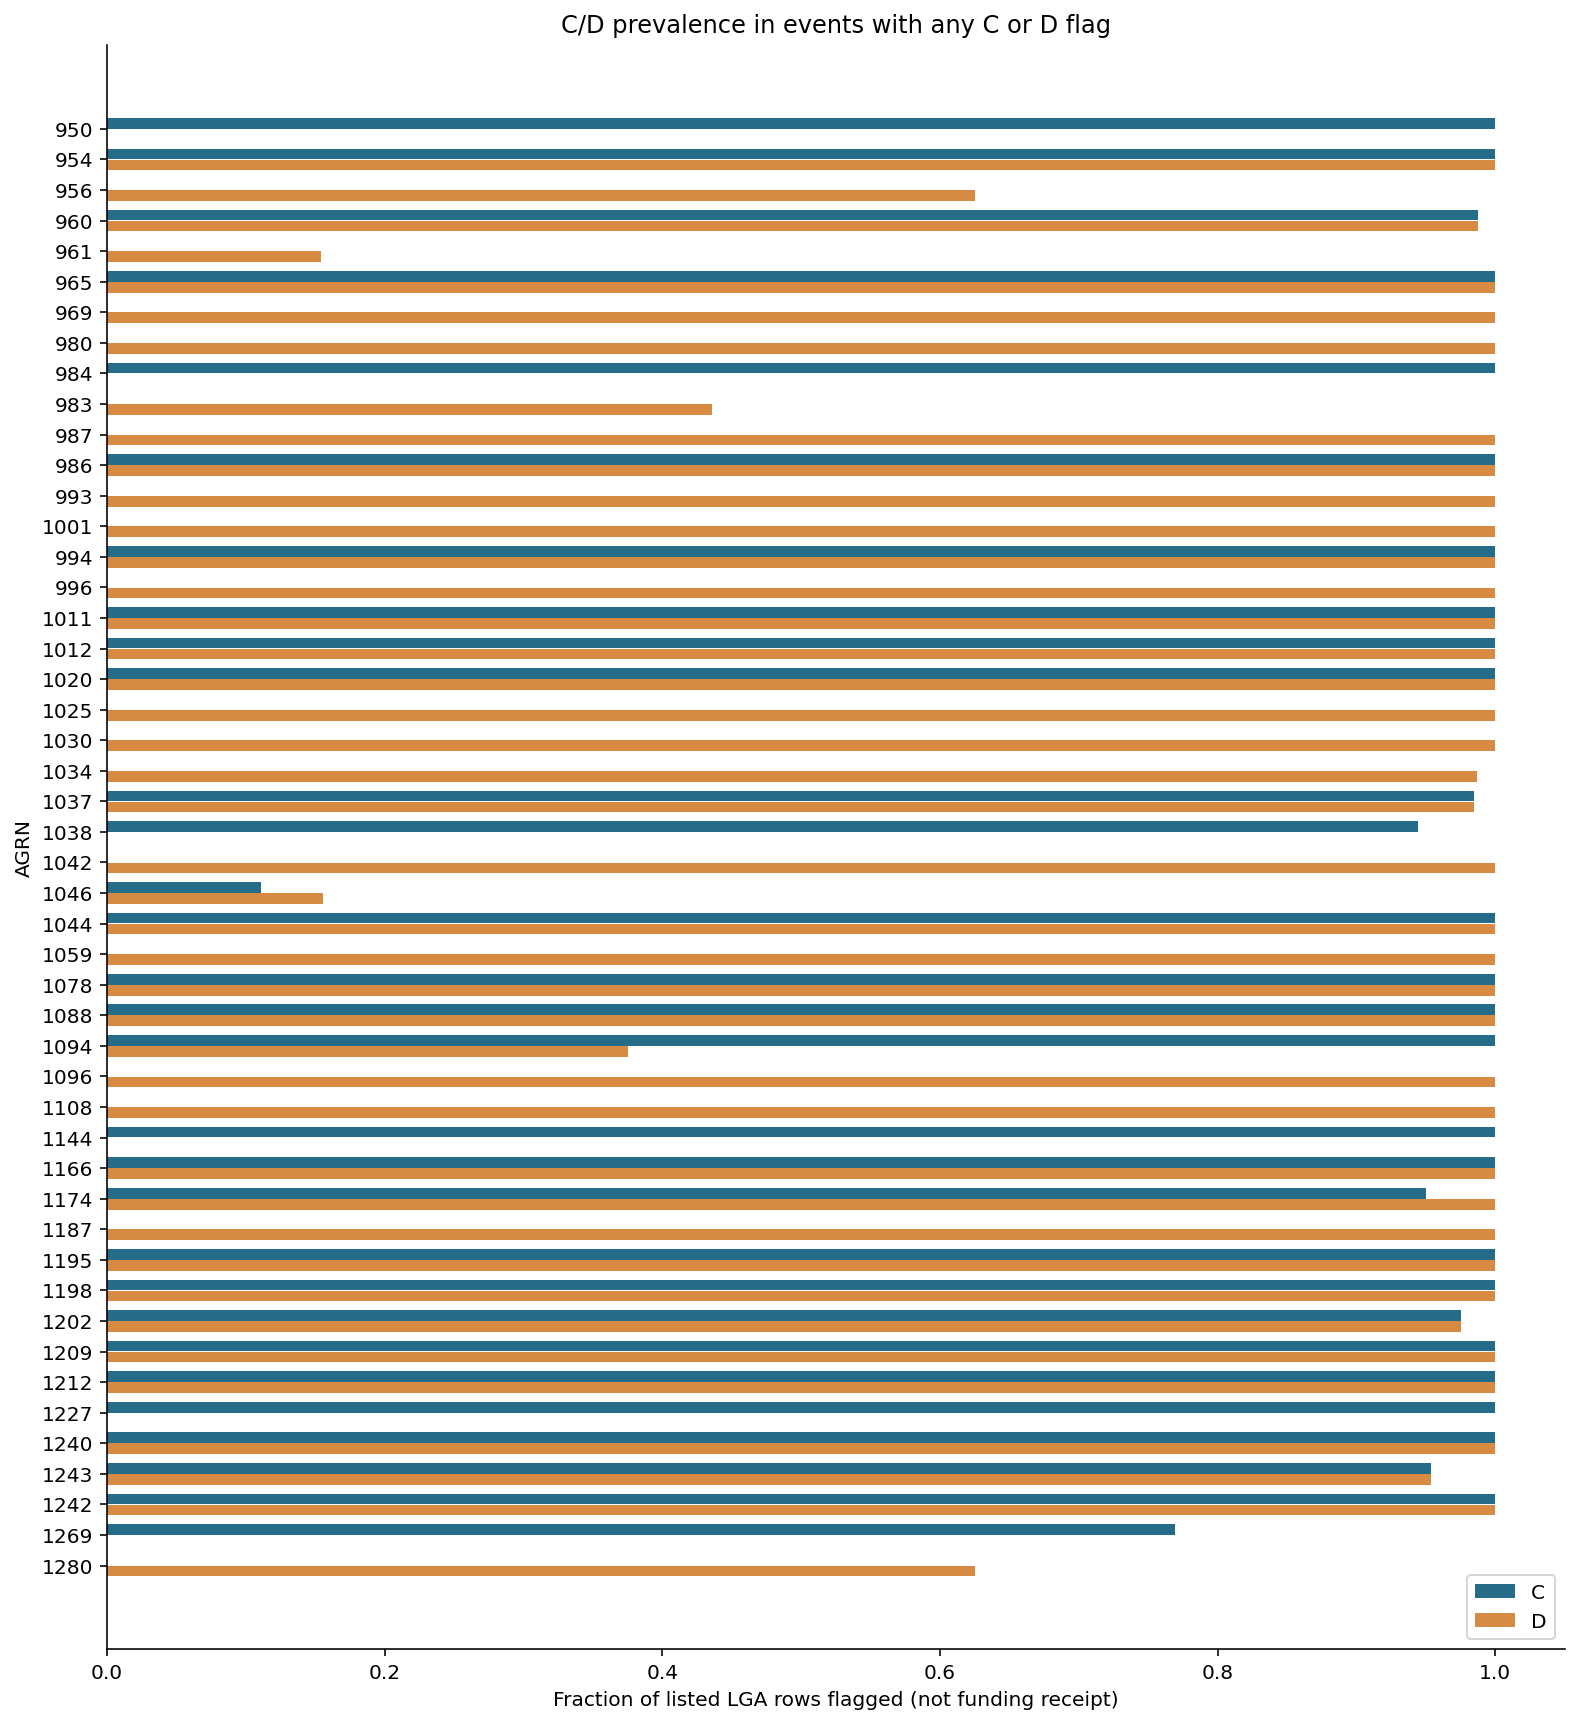

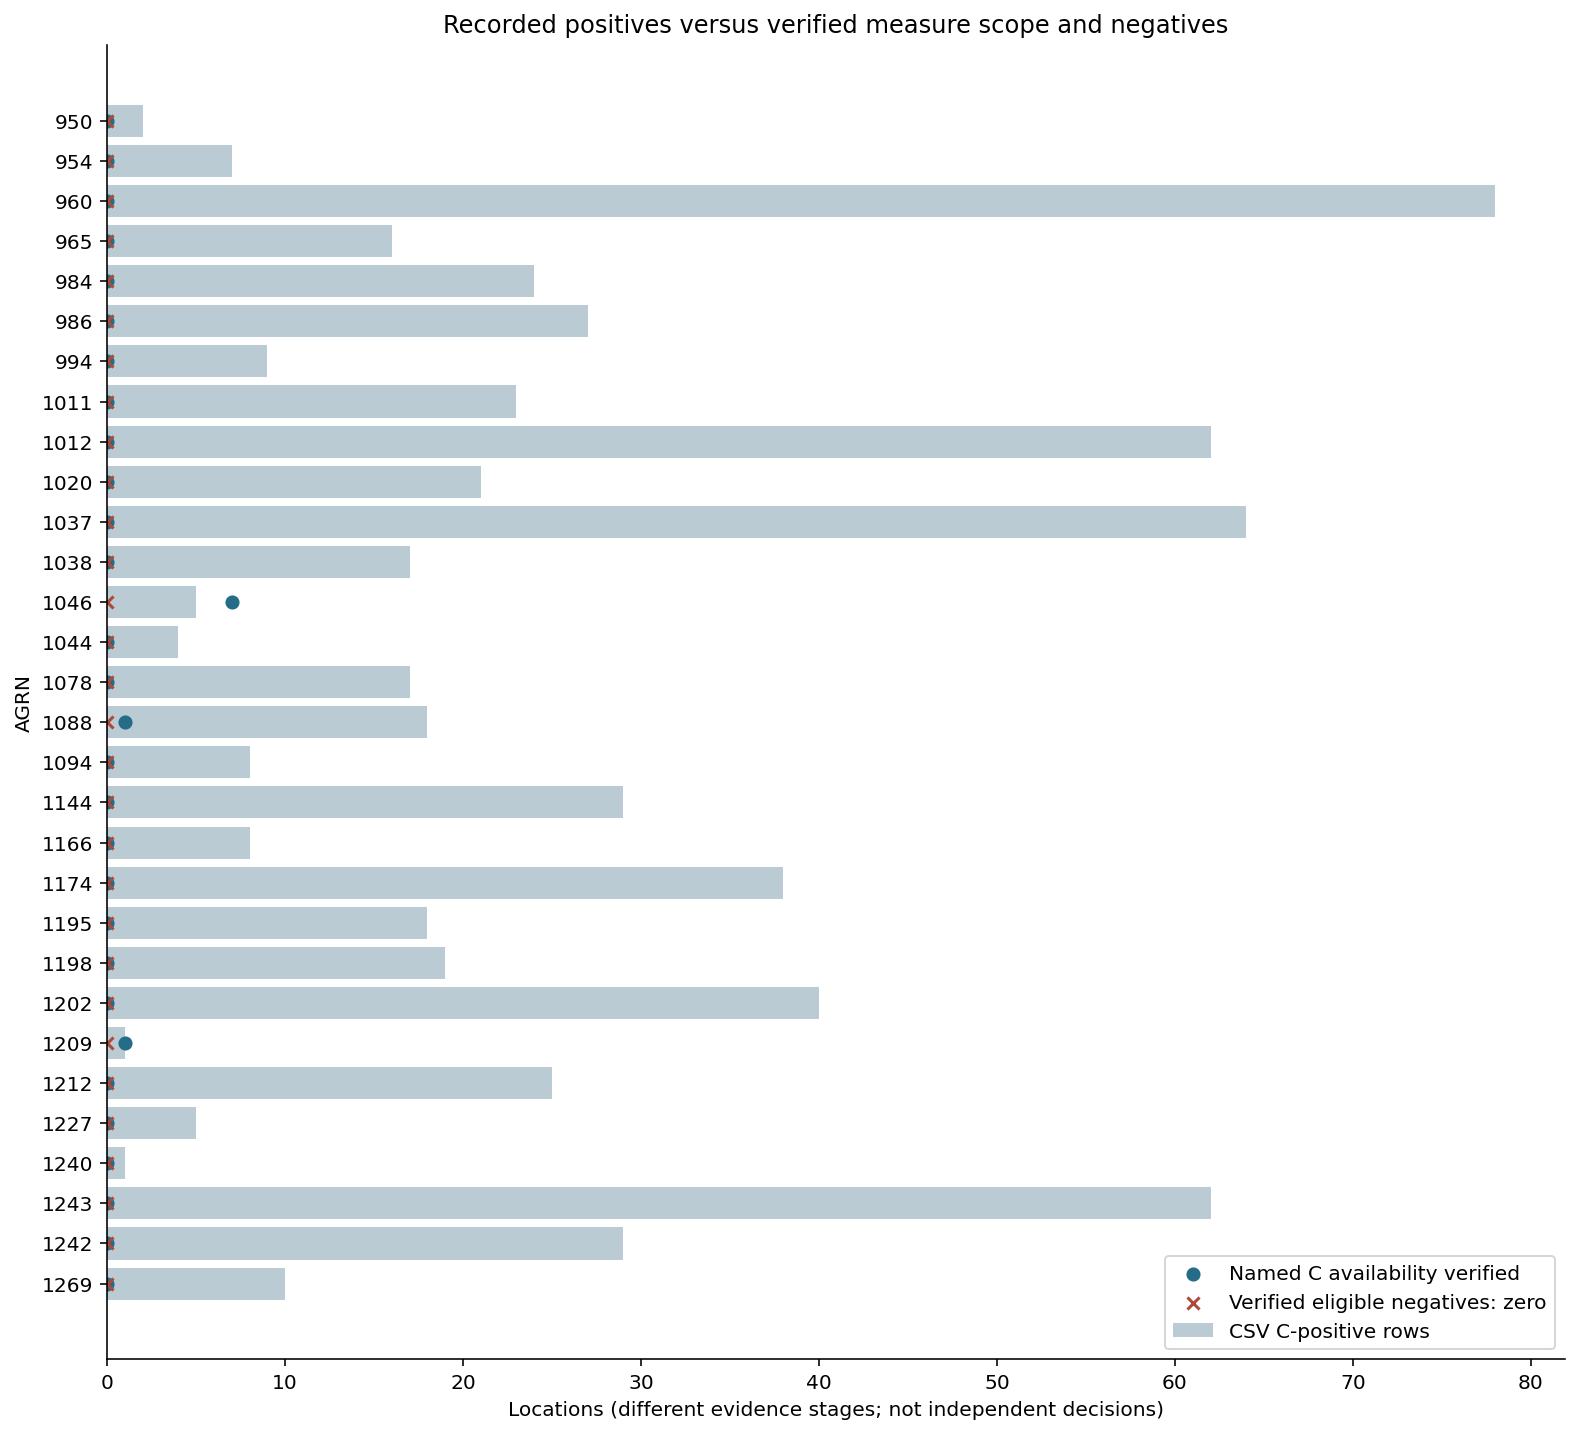

In [3]:
events = table("event_category_summary")
display(events.loc[events.cat_C_pattern.eq("mixed-C"), ["agrn", "state", "n_lga_rows", "cat_C_positive", "cat_C_zero"]])
figure("01_event_prevalence", 700)
figure("02_positives_negatives", 750)

## 4. Inspect the risk-set failure
Cloncurry and Mornington have C=0 in AGRN 1046, yet the official Category C tourism program names both in its geographic scope. This verifies availability, not receipt. Conversely, being outside a named program's scope is not an eligible rejection. Orange and Yarra have no A/B/C/D flags; individual disaster payments do not establish C eligibility.

The case ledger preserves these distinctions. **No defensible positive/eligible-negative contrast has been certified.** This does not prove no such decisions exist; the necessary administrative records are missing.

,agrn,Location_Name,measure_name,raw_cat_C,status
102,1046,Cloncurry,Tourism Recovery and Resilience Program,0,VERIFIED_POSITIVE
120,1046,Mornington,Tourism Recovery and Resilience Program,0,VERIFIED_POSITIVE


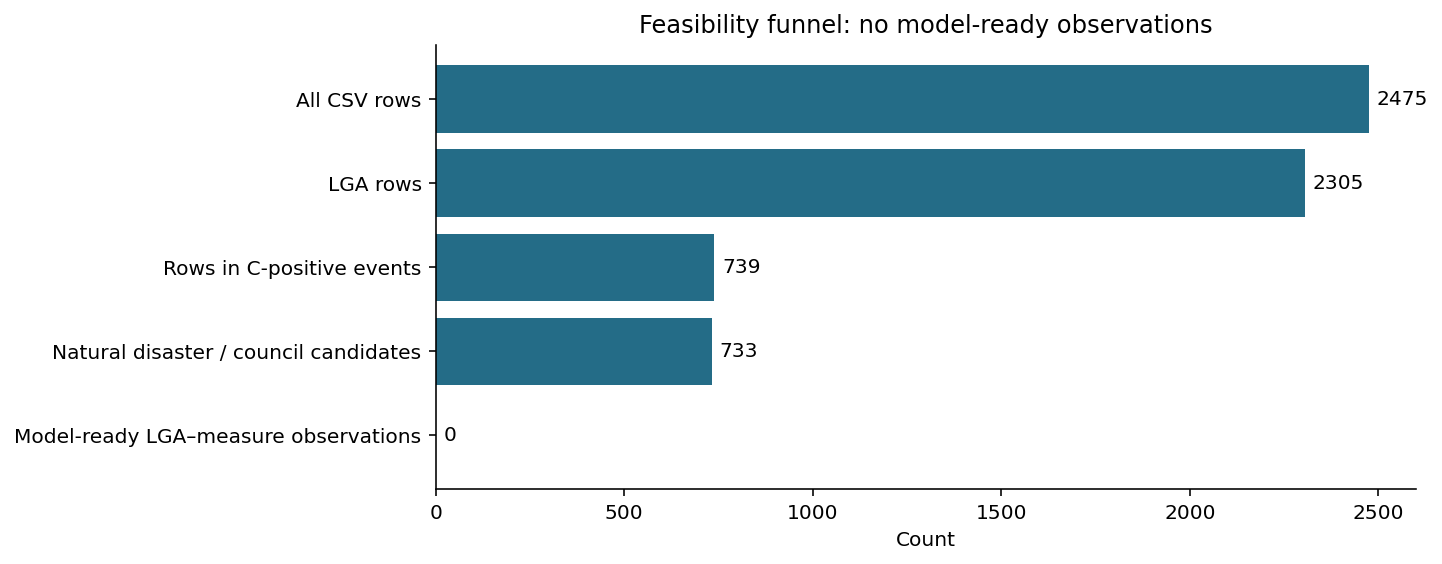

In [4]:
cases = table("positive_negative_case_audit")
display(cases.loc[cases.snapshot_conflict.eq(True), ["agrn", "Location_Name", "measure_name", "raw_cat_C", "status"]])
assert not cases.verified_eligible_negative.any()
figure("04_eligibility_filters")

## 5. Need, capacity and timing
Need is audited as 16 separate candidate variables across 30 events. Source availability is not measured event coverage: no complete independent, pre-decision need bundle is certified.

The NSW-only fiscal panel matches 157 of 739 C-event LGA rows. A prior financial period supplies 1,398 usable numeric values across nine fiscal/scale fields. All precede onset, but publication dates and historical vintages are not certified. Descriptive prior activation counts from the final snapshot are not certified ex-ante experience. Unknown timing stays unknown.

,feature,candidate_rows,observed_retrospective,strict_certified
0,cash_cover_months,739,155,0
1,current_ratio,739,155,0
2,debt_service_cover,739,153,0
3,debt_service_ratio_pct,739,155,0
4,grants_pct,739,156,0
5,operating_ratio_pct,739,155,0
6,own_source_pct,739,155,0
7,population,739,157,0
8,prior_funding_receipt_experience,739,0,0
9,prior_recorded_C_events,739,0,0


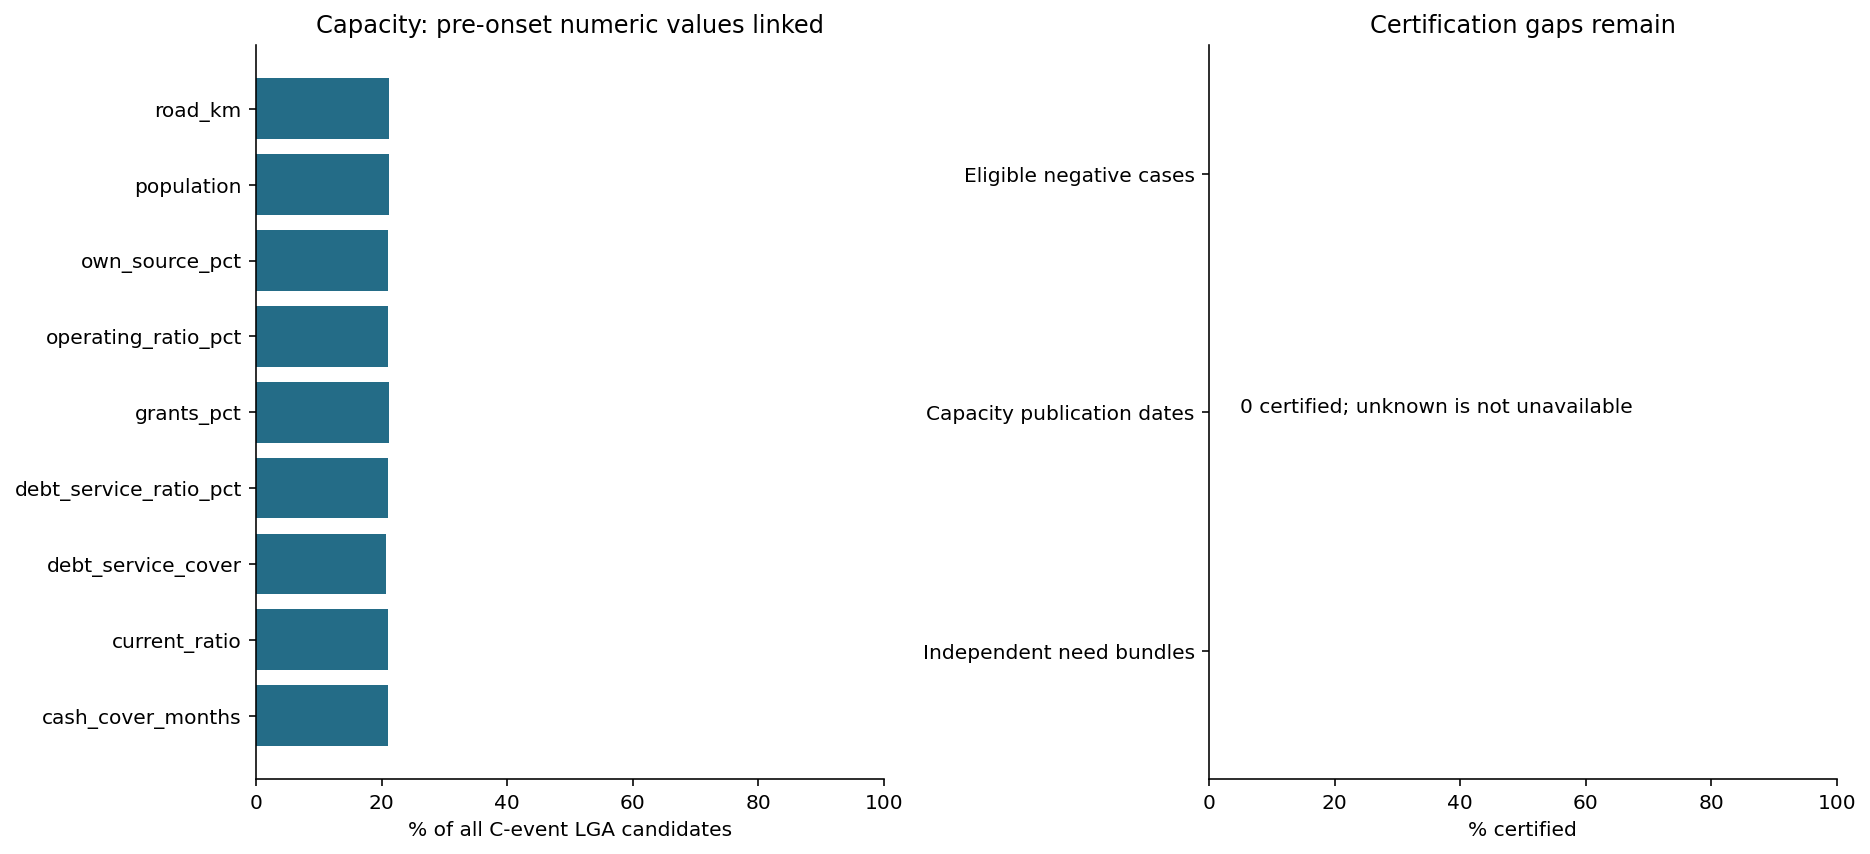

In [5]:
capacity = table("capacity_linkage_audit")
usable = capacity.loc[capacity.retrospective_eligible]
assert pd.to_datetime(usable.measurement_date).lt(pd.to_datetime(usable.disaster_start_date)).all()
display(table("capacity_coverage")[["feature", "candidate_rows", "observed_retrospective", "strict_certified"]])
figure("06_measurement_coverage", 1000)

## 6. Policy eras and effective sample size
There are 378 AGRNs in this extract, not 378 certified independent extraordinary-assistance decisions. The 30 C-positive events include a terrorist event and an unincorporated-area-only event; at most 28 remain as ordinary-council natural-disaster event candidates, before resolving shared packages and decision dependence.

The file has no C/D-positive records before 2021 despite a 2017 start and broader publisher coverage claims. This is a coverage warning, not evidence of no earlier assistance. National DRFA and state implementation changes require program-level comparison; C and D letters alone do not establish comparability.

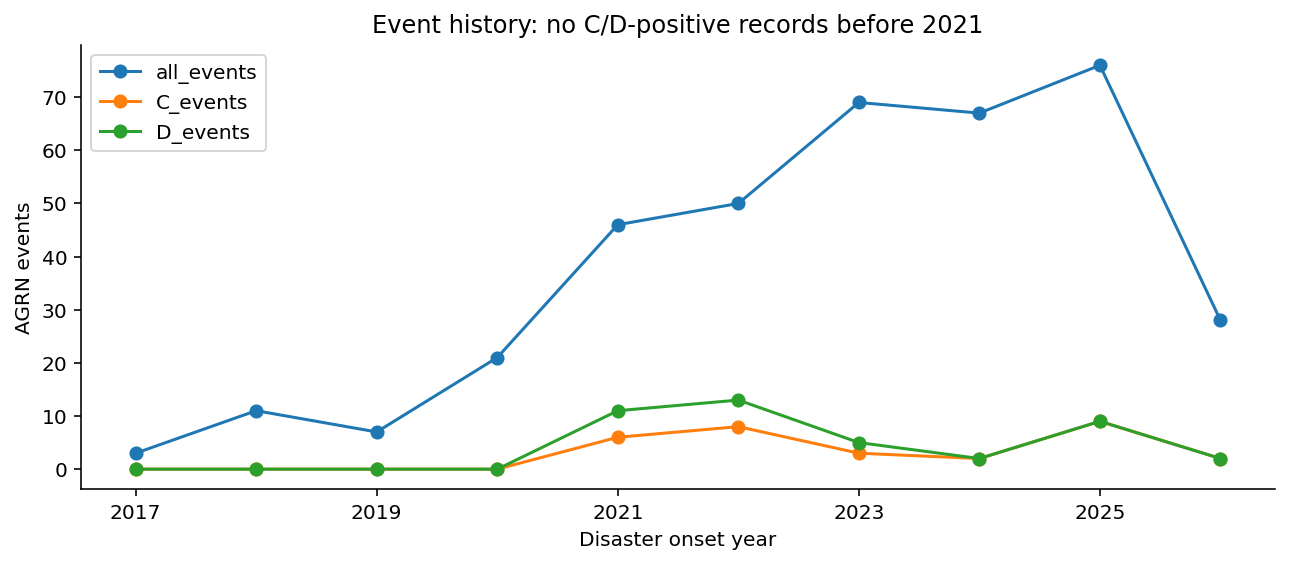

Verified eligible negatives: 0
Usable contrasts: 0


In [6]:
figure("05_event_timing")
print("Verified eligible negatives:", checks["verified_eligible_negatives"])
print("Usable contrasts:", checks["usable_contrasts"])
assert checks["existing_files_changed"] == []
assert checks["publisher_download_identical"] and checks["models_fitted"] == 0

## Verdict and next evidence
**NO-GO for the proposed pooled outcome; major redesign is required before modelling.** The outcome and eligible comparison population fail first, with independent need and nationwide capacity coverage also unresolved. More complex models cannot repair these measurement gaps.

A reconsideration would require a named, comparable assistance measure; the full set of eligible/considered locations or applicants; dated decisions and shared decision identifiers; independent damage/need records; and appropriately dated capacity data. The same CSV does not supply an automatically valid alternative receipt/denial outcome. No modelling plan is activated.

Full answers A–K, source links, policy qualifications and all inconclusive findings are in the [report](results/feasibility_report.md). The [output guide](results/README.md) explains every audit table. All six figures are descriptive; no classifier results were generated.